# 06 Transformer Tuning Experiments

This notebook tries the two ideas we discussed for reducing transformer lag:

- a **stronger transformer setup** with a larger hidden size, longer lookback, lower learning rate, and more regularization,
- an **expanded fast-reaction feature set** that adds shorter-horizon and range-based market signals.

The point is not to run a huge search. The point is to get evidence about whether lag is mostly a modeling problem, a feature problem, or both.

In [1]:
from pathlib import Path
import copy
import math
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run 01_data_download_and_features.ipynb first: {MODEL_DF_PATH}'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

DEVICE

device(type='mps')

## Feature sets to compare

The first experiment keeps the original transformer feature set and only strengthens the model/training setup.

The second experiment adds a small group of **fast-reaction features**:

- shorter-horizon volatility and volume signals,
- more market range features,
- extra VIX short-horizon dynamics.

If this second experiment wins, that is a concrete sign that the lag is not just architectural; the model also wants faster inputs.

In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date'])

base_features = [
    'abs_return', 'squared_return', 'high_low_log_range', 'log_volume',
    'realized_vol_5d', 'realized_vol_21d', 'realized_vol_63d',
    'hist_vol_5d', 'hist_vol_21d',
    'volume_zscore_21d', 'abs_return_mean_5d', 'parkinson_vol_5d',
    'mkt_SPY_proxy_return', 'mkt_SPY_proxy_hist_vol_5d',
    'mkt_QQQ_proxy_return', 'mkt_QQQ_proxy_hist_vol_21d',
    'mkt_IWM_proxy_return',
    'macro_^VIX_proxy_level_zscore_21d', 'macro_^TNX_proxy_return',
    'macro_HYG_proxy_return', 'macro_LQD_proxy_return',
]

fast_extra_features = [
    'volume_zscore_5d',
    'return_mean_5d',
    'realized_vol_10d',
    'parkinson_vol_21d',
    'mkt_SPY_proxy_range',
    'mkt_QQQ_proxy_range',
    'mkt_IWM_proxy_range',
    'macro_^VIX_proxy_return',
    'macro_^VIX_proxy_hist_vol_5d',
    'macro_^VIX_proxy_range',
]

experiment_feature_sets = {
    'tuned_base': base_features,
    'tuned_fast_features': base_features + fast_extra_features,
}

selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']
target_columns = ['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d']
model_df = model_df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

pd.DataFrame({
    'experiment': list(experiment_feature_sets.keys()),
    'feature_count': [len(v) for v in experiment_feature_sets.values()],
})

,experiment,feature_count
0,tuned_base,21
1,tuned_fast_features,31


## Shared tuned configuration

Both experiments use the same stronger transformer setup. That way the only thing that changes between them is the feature set.

In [3]:
config = {
    'lookback': 90,
    'batch_size': 512,
    'epochs': 30,
    'patience': 6,
    'learning_rate': 5e-4,
    'weight_decay': 5e-4,
    'd_model': 128,
    'nhead': 4,
    'num_layers': 2,
    'dim_feedforward': 256,
    'dropout': 0.2,
    'ticker_embedding_dim': 8,
    'train_end_year': 2023,
    'validation_year': 2024,
    'test_year': 2025,
}
config

{'lookback': 90,
 'batch_size': 512,
 'epochs': 30,
 'patience': 6,
 'learning_rate': 0.0005,
 'weight_decay': 0.0005,
 'd_model': 128,
 'nhead': 4,
 'num_layers': 2,
 'dim_feedforward': 256,
 'dropout': 0.2,
 'ticker_embedding_dim': 8,
 'train_end_year': 2023,
 'validation_year': 2024,
 'test_year': 2025}

In [4]:
class RollingSequenceDataset(Dataset):
    def __init__(self, grouped_data, ticker_to_idx, lookback, allowed_years):
        self.grouped_data = grouped_data
        self.ticker_to_idx = ticker_to_idx
        self.lookback = lookback
        self.allowed_years = set(allowed_years)
        self.samples = []
        for ticker, panel in grouped_data.items():
            for end_idx in range(lookback - 1, len(panel['dates'])):
                if panel['dates'][end_idx].year in self.allowed_years:
                    self.samples.append((ticker, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ticker, end_idx = self.samples[idx]
        panel = self.grouped_data[ticker]
        start_idx = end_idx - self.lookback + 1
        x = panel['features'][start_idx:end_idx + 1]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'ticker_idx': torch.tensor(self.ticker_to_idx[ticker], dtype=torch.long),
            'y_log': torch.tensor(panel['target_log'][end_idx], dtype=torch.float32),
            'y_vol': torch.tensor(panel['target_vol'][end_idx], dtype=torch.float32),
            'date': panel['dates'][end_idx].strftime('%Y-%m-%d'),
            'ticker': ticker,
        }

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class VolatilityTransformer(nn.Module):
    def __init__(self, input_dim, num_tickers, d_model, nhead, num_layers, dim_feedforward, dropout, ticker_embedding_dim, max_len):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=dropout, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.ticker_embedding = nn.Embedding(num_tickers, ticker_embedding_dim)
        self.head = nn.Sequential(
            nn.Linear(d_model + ticker_embedding_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, ticker_idx):
        x = self.input_proj(x)
        x = self.positional_encoding(x)
        encoded = self.encoder(x)
        sequence_repr = encoded[:, -1, :]
        ticker_repr = self.ticker_embedding(ticker_idx)
        output = self.head(torch.cat([sequence_repr, ticker_repr], dim=1)).squeeze(-1)
        return output

def volatility_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-8, None)
    errors = y_true - y_pred
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
    }

def run_epoch(model, dataloader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_items = 0
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        y_log = batch['y_log'].to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(x, ticker_idx)
            loss = criterion(pred, y_log)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_items += batch_size
    return total_loss / total_items

@torch.no_grad()
def predict_dataset(model, dataloader):
    model.eval()
    rows = []
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        pred_log = model(x, ticker_idx).detach().cpu().numpy()
        pred_vol = np.exp(pred_log)
        y_vol = batch['y_vol'].detach().cpu().numpy()
        for date, ticker, actual, prediction in zip(batch['date'], batch['ticker'], y_vol, pred_vol):
            rows.append({
                'Date': pd.to_datetime(date),
                'Ticker': ticker,
                'fvol_5d': float(actual),
                'prediction': float(prediction),
            })
    return pd.DataFrame(rows)


In [5]:
def prepare_experiment_data(feature_list):
    experiment_df = model_df[target_columns + feature_list].copy().sort_values(['Ticker', 'Date']).reset_index(drop=True)
    train_mask = experiment_df['Date'].dt.year <= config['train_end_year']
    feature_mean = experiment_df.loc[train_mask, feature_list].mean()
    feature_std = experiment_df.loc[train_mask, feature_list].std().replace(0, 1).fillna(1)
    experiment_df[feature_list] = (experiment_df[feature_list] - feature_mean) / feature_std
    ticker_levels = sorted(experiment_df['Ticker'].unique())
    ticker_to_idx = {ticker: idx for idx, ticker in enumerate(ticker_levels)}
    grouped_panels = {}
    for ticker, group in experiment_df.groupby('Ticker', sort=True):
        group = group.sort_values('Date').reset_index(drop=True)
        grouped_panels[ticker] = {
            'dates': group['Date'].tolist(),
            'features': group[feature_list].to_numpy(dtype=np.float32),
            'target_log': group['log_fvol_5d'].to_numpy(dtype=np.float32),
            'target_vol': group['fvol_5d'].to_numpy(dtype=np.float32),
        }
    train_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, config['lookback'], allowed_years=range(2016, config['train_end_year'] + 1))
    val_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, config['lookback'], allowed_years=[config['validation_year']])
    test_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, config['lookback'], allowed_years=[config['test_year']])
    return {
        'ticker_levels': ticker_levels,
        'ticker_to_idx': ticker_to_idx,
        'train_loader': DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, num_workers=0),
        'val_loader': DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=0),
        'test_loader': DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=0),
        'train_samples': len(train_dataset),
        'val_samples': len(val_dataset),
        'test_samples': len(test_dataset),
    }

def train_experiment(name, feature_list):
    data = prepare_experiment_data(feature_list)
    model = VolatilityTransformer(
        input_dim=len(feature_list),
        num_tickers=len(data['ticker_levels']),
        d_model=config['d_model'],
        nhead=config['nhead'],
        num_layers=config['num_layers'],
        dim_feedforward=config['dim_feedforward'],
        dropout=config['dropout'],
        ticker_embedding_dim=config['ticker_embedding_dim'],
        max_len=config['lookback'],
    ).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])
    best_state = None
    best_val_loss = float('inf')
    best_epoch = None
    epochs_without_improvement = 0
    history_rows = []
    for epoch in range(1, config['epochs'] + 1):
        train_loss = run_epoch(model, data['train_loader'], criterion, optimizer=optimizer)
        val_loss = run_epoch(model, data['val_loader'], criterion, optimizer=None)
        history_rows.append({'experiment': name, 'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        print(f"{name} | epoch {epoch}/{config['epochs']} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")
        if epochs_without_improvement >= config['patience']:
            print(f"{name} | early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
            break
    model.load_state_dict(best_state)
    val_predictions = predict_dataset(model, data['val_loader'])
    test_predictions = predict_dataset(model, data['test_loader'])
    val_metrics = volatility_metrics(val_predictions['fvol_5d'], val_predictions['prediction'])
    test_metrics = volatility_metrics(test_predictions['fvol_5d'], test_predictions['prediction'])
    summary = {
        'experiment': name,
        'feature_count': len(feature_list),
        'train_samples': data['train_samples'],
        'val_samples': data['val_samples'],
        'test_samples': data['test_samples'],
        'best_epoch': best_epoch,
        'val_rmse': val_metrics['rmse'],
        'val_mae': val_metrics['mae'],
        'val_qlike': val_metrics['qlike'],
        'test_rmse': test_metrics['rmse'],
        'test_mae': test_metrics['mae'],
        'test_qlike': test_metrics['qlike'],
    }
    return summary, pd.DataFrame(history_rows), test_predictions


## Run the two experiments

This takes longer than the single-baseline notebook because we train two tuned transformers back-to-back, but the result is much more informative.

In [6]:
experiment_summaries = []
history_frames = []
test_prediction_map = {}

for experiment_name, feature_list in experiment_feature_sets.items():
    summary, history_df, test_predictions_df = train_experiment(experiment_name, feature_list)
    experiment_summaries.append(summary)
    history_frames.append(history_df)
    test_prediction_map[experiment_name] = test_predictions_df

experiment_summary_df = pd.DataFrame(experiment_summaries).sort_values('val_rmse').reset_index(drop=True)
history_df = pd.concat(history_frames, ignore_index=True)
best_experiment = experiment_summary_df.iloc[0]['experiment']

experiment_summary_df

tuned_base | epoch 1/30 | train_loss=0.282021 | val_loss=0.243266


tuned_base | epoch 2/30 | train_loss=0.229367 | val_loss=0.243611


tuned_base | epoch 3/30 | train_loss=0.220069 | val_loss=0.269783


tuned_base | epoch 4/30 | train_loss=0.211214 | val_loss=0.252781


tuned_base | epoch 5/30 | train_loss=0.205403 | val_loss=0.269376


...

tuned_fast_features | epoch 4/30 | train_loss=0.208088 | val_loss=0.272618


tuned_fast_features | epoch 5/30 | train_loss=0.201383 | val_loss=0.270741


tuned_fast_features | epoch 6/30 | train_loss=0.195341 | val_loss=0.293975


tuned_fast_features | epoch 7/30 | train_loss=0.189945 | val_loss=0.278461
tuned_fast_features | early stopping at epoch 7. Best epoch: 1.


,experiment,feature_count,train_samples,val_samples,test_samples,best_epoch,val_rmse,val_mae,val_qlike,test_rmse,test_mae,test_qlike
0,tuned_fast_features,31,101750,13860,13475,1,0.141722,0.082484,-1.581025,0.161581,0.095213,-1.253572
1,tuned_base,21,101750,13860,13475,1,0.143597,0.083731,-1.564598,0.166838,0.098952,-1.275959


In [7]:
history_df

,experiment,epoch,train_loss,val_loss
0,tuned_base,1,0.282021,0.243266
1,tuned_base,2,0.229367,0.243611
2,tuned_base,3,0.220069,0.269783
3,tuned_base,4,0.211214,0.252781
4,tuned_base,5,0.205403,0.269376
5,tuned_base,6,0.200217,0.269233
6,tuned_base,7,0.196666,0.244533
7,tuned_fast_features,1,0.310094,0.237553
8,tuned_fast_features,2,0.229600,0.271369
9,tuned_fast_features,3,0.217494,0.262866


## Compare prediction curves on the same five stocks

Each subplot overlays the actual realized volatility with both tuned transformer experiments. This is the easiest way to judge whether the extra fast features really help with lag.

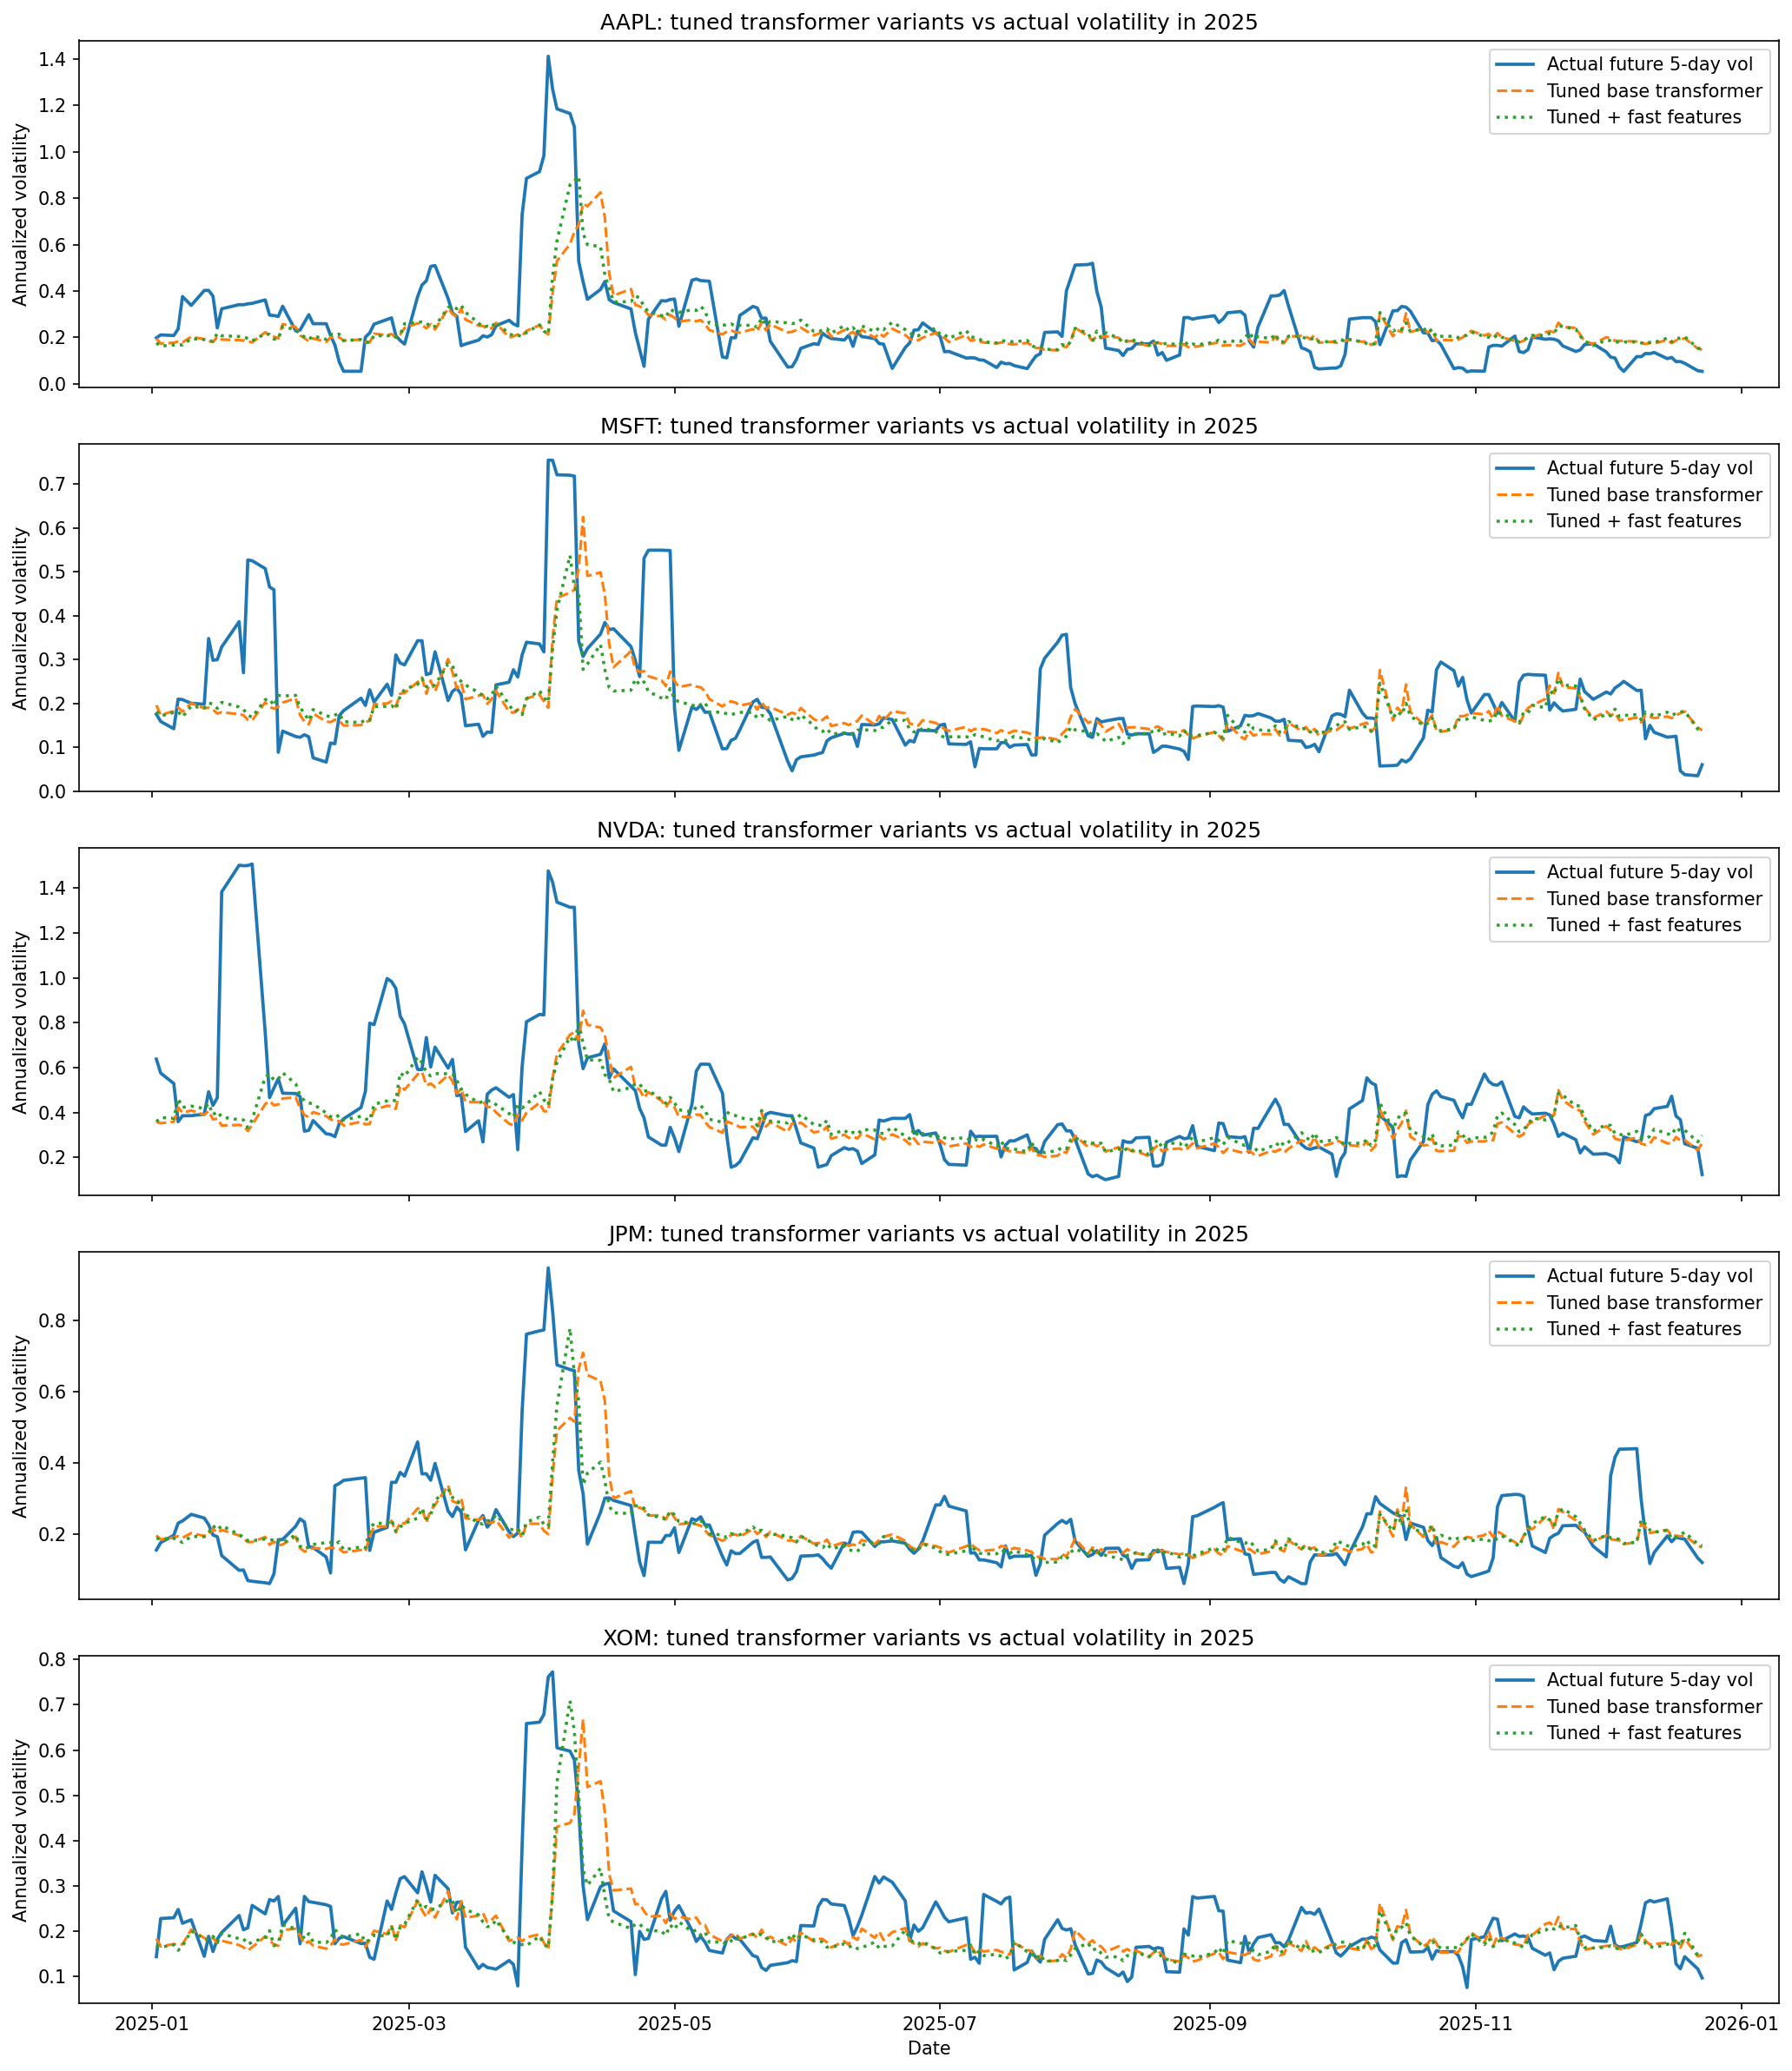

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/transformer_tuning_test_predictions_5stocks.png')

In [8]:
plot_df = test_prediction_map['tuned_base'].rename(columns={'prediction': 'tuned_base'})
plot_df = plot_df.merge(
    test_prediction_map['tuned_fast_features'][['Date', 'Ticker', 'prediction']].rename(columns={'prediction': 'tuned_fast_features'}),
    on=['Date', 'Ticker'],
    how='left'
)

fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 16), sharex=True)

for ax, ticker in zip(axes, selected_tickers):
    stock_plot_df = plot_df[plot_df['Ticker'] == ticker].sort_values('Date')
    ax.plot(stock_plot_df['Date'], stock_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.8)
    ax.plot(stock_plot_df['Date'], stock_plot_df['tuned_base'], label='Tuned base transformer', linestyle='--', linewidth=1.5)
    ax.plot(stock_plot_df['Date'], stock_plot_df['tuned_fast_features'], label='Tuned + fast features', linestyle=':', linewidth=1.7)
    ax.set_title(f'{ticker}: tuned transformer variants vs actual volatility in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()

tuning_plot_path = FIGURE_DIR / 'transformer_tuning_test_predictions_5stocks.png'
plt.savefig(tuning_plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(tuning_plot_path)))

tuning_plot_path

## How to interpret the result

The summary table answers both questions directly:

- if `tuned_base` improves a lot, the main issue was model capacity / training setup,
- if `tuned_fast_features` improves further, the lag also wanted faster inputs,
- if neither helps much, then the lag is probably tied more fundamentally to the target definition and the difficulty of forecasting volatility spikes.